In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
file_path = 'diabetes_012_health_indicators_BRFSS2015.csv'
#uploaded = files.upload()

In [ ]:
data = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [ ]:
print(data.describe().T)

                         count       mean       std   min   25%   50%   75%  \
Diabetes_012          253680.0   0.296921  0.698160   0.0   0.0   0.0   0.0   
HighBP                253680.0   0.429001  0.494934   0.0   0.0   0.0   1.0   
HighChol              253680.0   0.424121  0.494210   0.0   0.0   0.0   1.0   
CholCheck             253680.0   0.962670  0.189571   0.0   1.0   1.0   1.0   
BMI                   253680.0  28.382364  6.608694  12.0  24.0  27.0  31.0   
Smoker                253680.0   0.443169  0.496761   0.0   0.0   0.0   1.0   
Stroke                253680.0   0.040571  0.197294   0.0   0.0   0.0   0.0   
HeartDiseaseorAttack  253680.0   0.094186  0.292087   0.0   0.0   0.0   0.0   
PhysActivity          253680.0   0.756544  0.429169   0.0   1.0   1.0   1.0   
Fruits                253680.0   0.634256  0.481639   0.0   0.0   1.0   1.0   
Veggies               253680.0   0.811420  0.391175   0.0   1.0   1.0   1.0   
HvyAlcoholConsump     253680.0   0.056197  0.230302 

In [ ]:
print(data.isnull().sum())

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


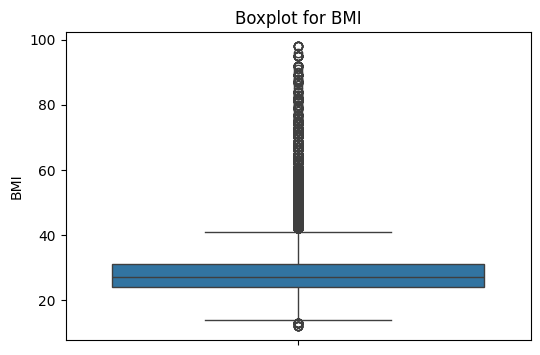

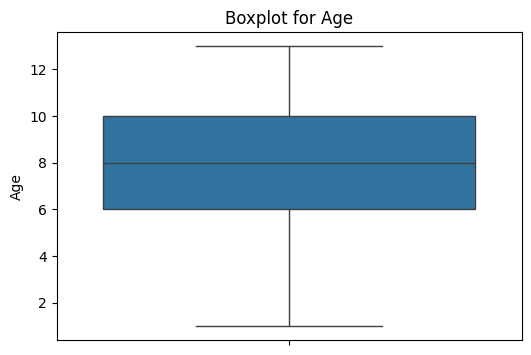

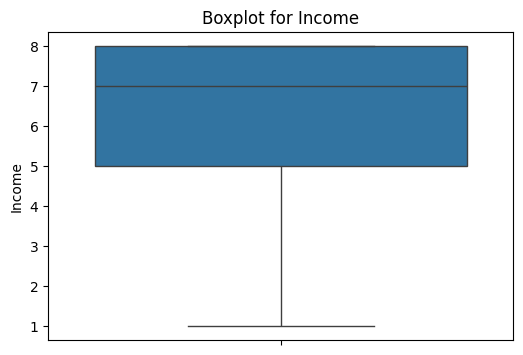

In [ ]:
# Univariate Analysis: Boxplots to check for outliers in continuous features
continuous_features = ['BMI', 'Age', 'Income']
for feature in continuous_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data[feature])
    plt.title(f'Boxplot for {feature}')
    plt.show()

In [ ]:
# Handling outliers: Capping values at the 1st and 99th percentiles
for feature in continuous_features:
    lower_cap = data[feature].quantile(0.01)
    upper_cap = data[feature].quantile(0.99)
    data[feature] = np.where(data[feature] < lower_cap, lower_cap,
                             np.where(data[feature] > upper_cap, upper_cap, data[feature]))

In [ ]:
from sklearn.preprocessing import StandardScaler

# Applying standard scaling to continuous features
scaler = StandardScaler()
data[continuous_features] = scaler.fit_transform(data[continuous_features])

In [ ]:
# Feature Engineering: Create binary 'HighBMI' feature
data['HighBMI'] = (data['BMI'] > 30).astype(int)

In [ ]:
# Risk Factor Score: Sum of binary risk features
risk_factors = ['HighBP', 'HighChol', 'Smoker', 'HighBMI']
data['RiskFactorScore'] = data[risk_factors].sum(axis=1)

In [ ]:
# Resilience label: High risk with no chronic conditions
data['Resilient'] = np.where(
    (data['RiskFactorScore'] >= 2) &
    (data['Diabetes_012'] == 0) &
    (data['HeartDiseaseorAttack'] == 0) &
    (data['Stroke'] == 0), 1, 0
)

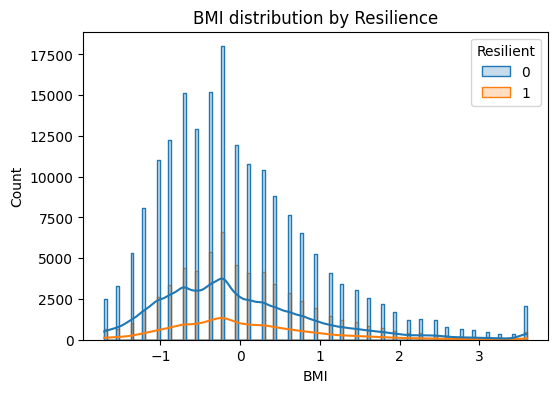

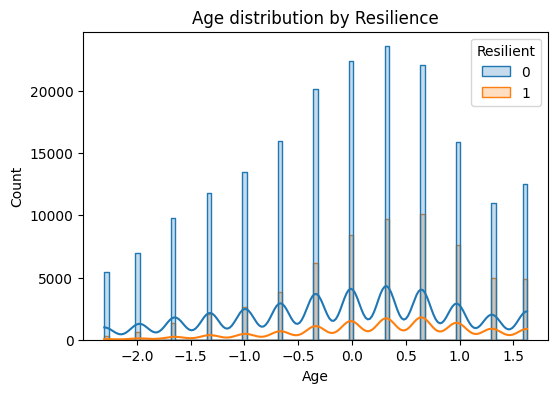

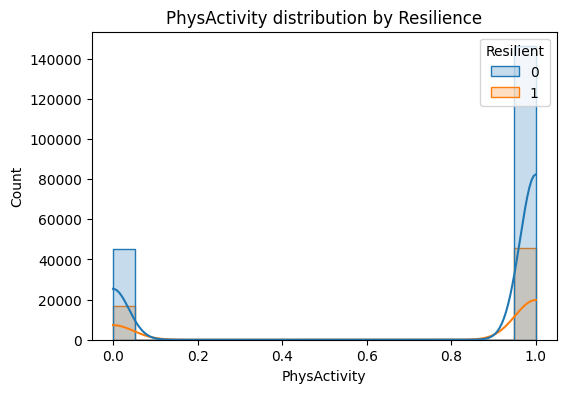

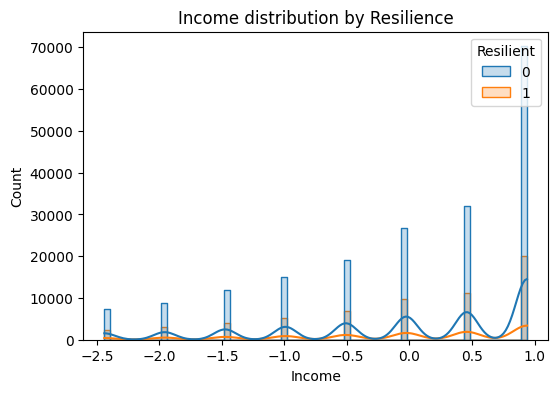

In [ ]:
# Distribution of key features across Resilient and Non-Resilient groups
for feature in ['BMI', 'Age', 'PhysActivity', 'Income']:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=data, x=feature, hue='Resilient', kde=True, element="step")
    plt.title(f'{feature} distribution by Resilience')
    plt.show()

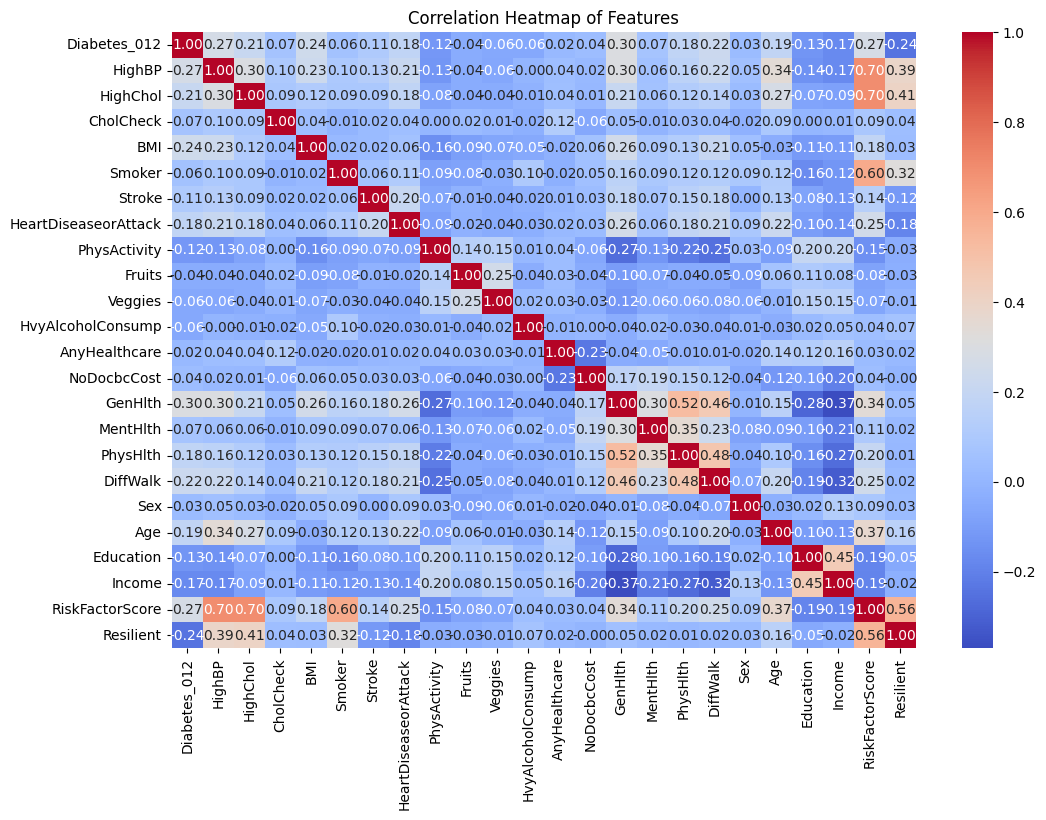

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = data.drop(columns=['HighBMI']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# Define features (X) and target (y)
X = data.drop(columns=['Resilient', 'Diabetes_012', 'HeartDiseaseorAttack', 'Stroke'])  # Drop target and outcome labels
y = data['Resilient']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Check class balance
print("Class distribution in target variable:\n", y.value_counts(normalize=True))

Class distribution in target variable:
 Resilient
0    0.753264
1    0.246736
Name: proportion, dtype: float64


In [ ]:
# Handle class imbalance using SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

In [ ]:
# Initialize all models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, class_weight="balanced"),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
    'Artificial Neural Network (ANN)': MLPClassifier(hidden_layer_sizes=(50,), max_iter=100, random_state=42)
}


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.89      0.91     38107
           1       0.71      0.78      0.74     12629

    accuracy                           0.86     50736
   macro avg       0.82      0.84      0.83     50736
weighted avg       0.87      0.86      0.87     50736



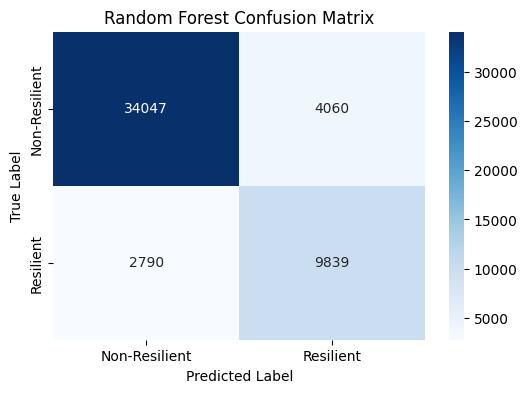


XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.90      0.92     38107
           1       0.72      0.81      0.76     12629

    accuracy                           0.88     50736
   macro avg       0.83      0.85      0.84     50736
weighted avg       0.88      0.88      0.88     50736



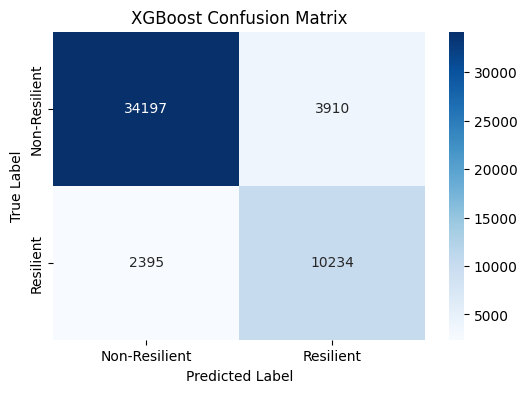


Gradient Boosting Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.82      0.89     38107
           1       0.64      0.96      0.77     12629

    accuracy                           0.85     50736
   macro avg       0.81      0.89      0.83     50736
weighted avg       0.90      0.85      0.86     50736



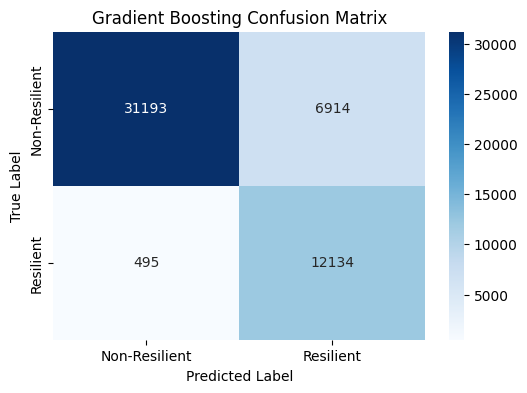

C:\Users\FLORA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(



Artificial Neural Network (ANN) Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.84      0.90     38107
           1       0.66      0.93      0.77     12629

    accuracy                           0.86     50736
   macro avg       0.81      0.88      0.84     50736
weighted avg       0.89      0.86      0.87     50736



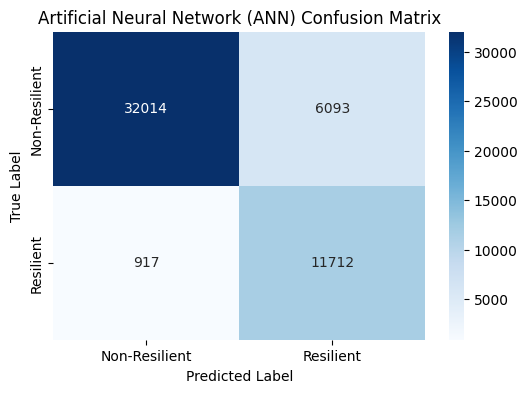

In [ ]:
# Prepare a list to store results
model_results = []

# Train and evaluate each model
for model_name, model in models.items():
    # Train the model
    model.fit(X_train_smote, y_train_smote)

    # Predict on the test set
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

    # Store results
    model_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'F1 Score': f1,
        'AUC-ROC': roc_auc
    })

    # Print classification report for each model
    print(f"\n{model_name} Classification Report:\n")
    print(classification_report(y_test, y_pred))

    # Plot confusion matrix for each model
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Resilient", "Resilient"], yticklabels=["Non-Resilient", "Resilient"])
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


Model Comparison Results:
                             Model  Accuracy  F1 Score   AUC-ROC
3  Artificial Neural Network (ANN)  0.861834  0.769666  0.945406
2                Gradient Boosting  0.853970  0.766108  0.944454
1                          XGBoost  0.875729  0.764502  0.946769
0                    Random Forest  0.864987  0.741782  0.937787


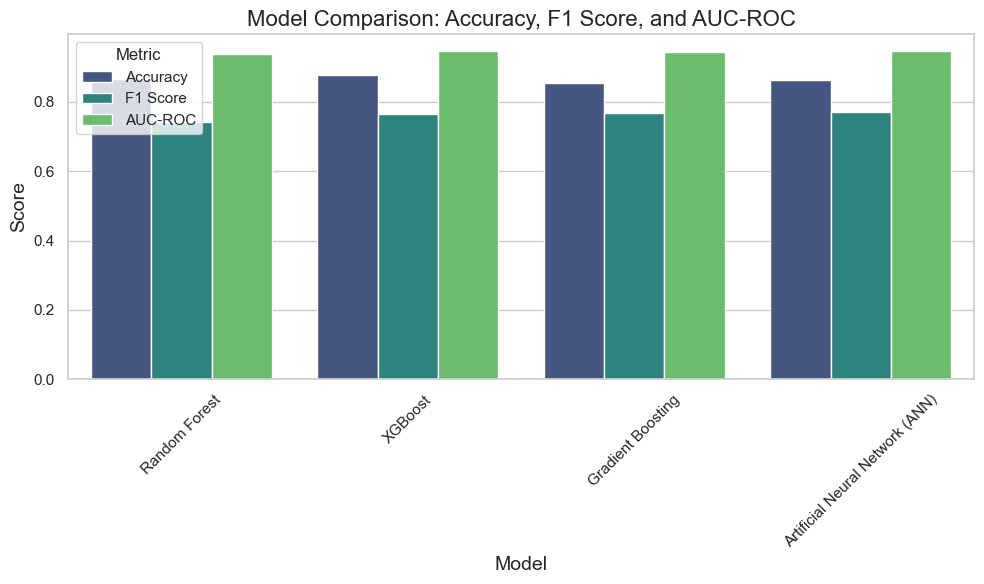

In [ ]:
# Convert results to a DataFrame for better readability
results_df = pd.DataFrame(model_results)
print("\nModel Comparison Results:")
print(results_df.sort_values(by='F1 Score', ascending=False))

# Create a comparison plot
sns.set(style="whitegrid")
model_comparison_melted = results_df.melt(id_vars="Model", value_vars=["Accuracy", "F1 Score", "AUC-ROC"])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='value', hue='variable', data=model_comparison_melted, palette='viridis')

# Customize the plot
plt.title('Model Comparison: Accuracy, F1 Score, and AUC-ROC', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Metric', loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
#Choose the best model based on the F1 Score or other metric
best_model_name = results_df.sort_values(by='F1 Score', ascending=False).iloc[0]['Model']
print(f"\nBest model based on F1 Score: {best_model_name}")


Best model based on F1 Score: Artificial Neural Network (ANN)


In [ ]:
# Select the best model based on the comparison
if best_model_name == 'Random Forest':
    best_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
elif best_model_name == 'Logistic Regression':
    best_model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=200)
elif best_model_name == 'Gradient Boosting':
    best_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
elif best_model_name == 'Artificial Neural Network (ANN)':
    best_model = MLPClassifier(random_state=42, max_iter=200, solver='adam', hidden_layer_sizes=(100,))
else:
    raise ValueError("Best model not recognized.")

In [ ]:
# Hyperparameter tuning for the best model using GridSearchCV
from sklearn.model_selection import GridSearchCV

# Parameter grids for each model

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 150],
        'max_depth': [10, 20, 30],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
        'max_iter': [100, 200]
    }
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 4]
    }
elif best_model_name == 'Artificial Neural Network (ANN)':
    param_grid = {
        'hidden_layer_sizes': [(50,), (100,)],
        'activation': ['relu', 'tanh'],
        'solver': ['adam', 'sgd'],
        'learning_rate_init': [0.001, 0.01]
    }

# Initialize GridSearchCV for the best model
grid_search = GridSearchCV(
    estimator=best_model,
    param_grid=param_grid,
    scoring='f1',
    cv=3,  # 3-fold cross-validation
    n_jobs=-1,
    verbose=2
)

# Step 4: Fit GridSearchCV
grid_search.fit(X_train_smote, y_train_smote)

# Output the best parameters and best score
print("\nBest Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Parameters: {'activation': 'tanh', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001, 'solver': 'sgd'}
Best F1 Score: 0.9033402597399846



Final Model Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.82      0.89     38107
           1       0.63      0.97      0.77     12629

    accuracy                           0.85     50736
   macro avg       0.81      0.89      0.83     50736
weighted avg       0.90      0.85      0.86     50736



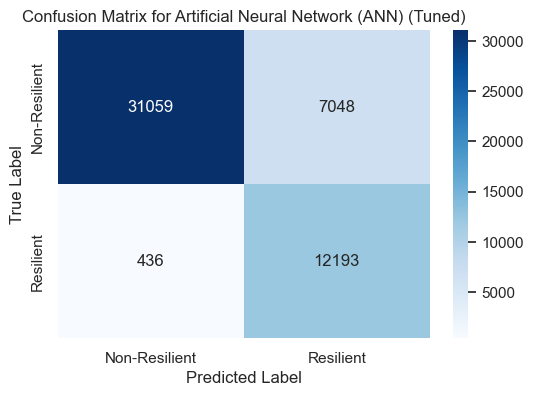

In [ ]:
# Retrain the best model with the best parameters
best_model_tuned = grid_search.best_estimator_
best_model_tuned.fit(X_train_smote, y_train_smote)

# Evaluate the tuned model
y_pred_best = best_model_tuned.predict(X_test)
y_pred_proba_best = best_model_tuned.predict_proba(X_test)[:, 1] if hasattr(best_model_tuned, "predict_proba") else None

# Final Classification Report for the tuned best model
print("\nFinal Model Classification Report:")
print(classification_report(y_test, y_pred_best))

# Plot confusion matrix for the tuned best model
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Resilient", "Resilient"], yticklabels=["Non-Resilient", "Resilient"])
plt.title(f"Confusion Matrix for {best_model_name} (Tuned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()